In [1]:
#
# Classification - Iris Flowers
#

In [2]:
## To eliminate the warning about the memory leaks from KMeans,
## you can either limit the whole Python script to a single thread
## (MUST be done at the beginning of the script):
## import os
## os.environ['OMP_NUM_THREADS'] = '1'
##
## Or, you can just supress the warning message
## (as the memory leak is negligeable):
import warnings
warnings.filterwarnings('ignore')
##
## choose the smaller evil :)

In [3]:
# import libraries
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
# load data (from the library)
data = load_iris()

In [5]:
#
# Dataset contains five fields: four inputs plus one output (classificator)
#
print('Dim of the X dataset:', data['data'].shape)
print('Dim of the Y dataset:', data['target'].shape)
#
# Four inputs are physical dimensions of a flower:
# 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'
X = data['data']
#
# Classificator (aka target) tells which type of iris flower that record belongs to
#
# There are three types of iris flowers: setosa, versicolor, virginica
# (and classificator tells which flower type each record belongs to)
Y = data['target']
#
# The purpose of the system is to predict (guess)
# which type of flower a new record belongs to -
# by looking at four inputs
#
print('Inputs:', data['feature_names'])
print('Output:', data['target_names'], '(one of these)')

Dim of the X dataset: (150, 4)
Dim of the Y dataset: (150,)
Inputs: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Output: ['setosa' 'versicolor' 'virginica'] (one of these)


In [6]:
#
# Preview the inputs
# (the first 6 rows)
#
data['data'][0:6]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4]])

In [7]:
#
# Preview the output
# classificator aka class aka target
#
Y[0:6,]        # the first 6 rows
data['target'] # all 150 rows
#
# 0,1,2 correspond to 'setosa', 'versicolor', 'virginica'

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
#
# Let's try visualising the dataset
#

In [9]:
# this array will be used to define colours for classes
colours=['orange', 'blue', 'green']

In [10]:
## The problem is: there are four inputs -
## therefore we would need 4 dimensions to visualise it
## well, strictly speaking we'd need 5 dimensions
## (including classificator)
## X-Y plane only allows to display 2 fields
## (three if we use colour)
##
## So we will inevitably lose some information
## when we visualise 3 dimensions out of 5

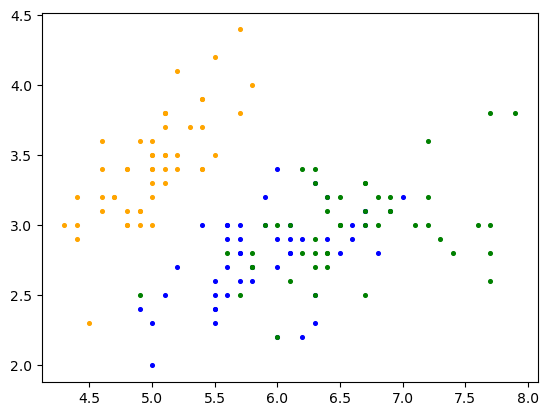

In [11]:
#
# Plot the data using columns 0 and 1
#
for i in range(X.shape[0]):
    plt.scatter(X[i, 0], X[i, 1], s=7, color = colours[int(Y[i])])
plt.show()

In [12]:
#
# What do you think - are they separated very well?
#
# Yellow class is separated OK,
# whilst blue and green seem to be mixed
#
# Mixed datapoints is not the biggest problem here
# The biggest problem is that centers of blue and green clusters are very close
# which means they overlap a lot
# (so the error rate will be very high)
#
# How the machine learning algorithm will perform data classification?
# We find center of each cluster and then
# measure the distance from new data point to those centers
# The closest center will 'win' - and that will be our prediction
#
# This algorithm is known as K-means clustering
#
# You have to understand that there will inevitably be classification errors
# (yellow cluster is more or less separated whilst green and blue are overlapping a lot -
# so centers of blue and green clusters are pretty close)
#
# Let's see how this algorithm is implemented into Python code
#

In [13]:
#
# Calculate centers of each cluster (columns 0 and 1)
#
Kmean = KMeans(n_clusters=3, n_init='auto')
Kmean.fit(X)
centers = Kmean.cluster_centers_
print('Centers of clusters (in 4D space):')
print(centers)

Centers of clusters (in 4D space):
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


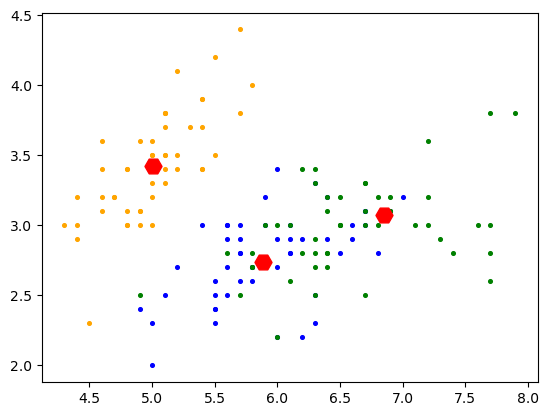

In [14]:
#
# Plot clusters centers (columns 0 and 1)
#
for i in range(X.shape[0]):
    plt.scatter(X[i, 0], X[i, 1], s=7, color = colours[int(Y[i])])
plt.scatter(centers[:,0], centers[:,1], marker='H', c='r', s=150)
plt.show()

In [15]:
#
# How will our clusters look like if we use different columns?
#

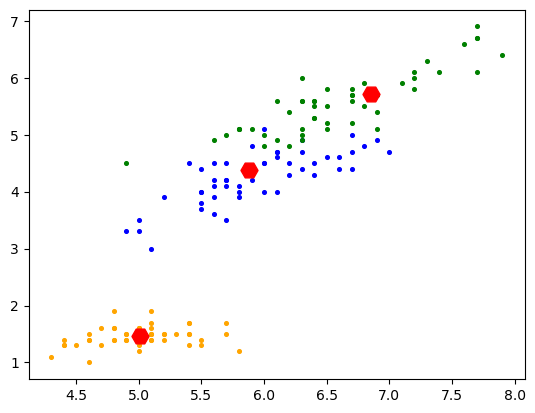

In [16]:
#
# Plot the data using columns 0 and 2
#
Kmean = KMeans(n_clusters=3, n_init='auto')
Kmean.fit(X)
centers = Kmean.cluster_centers_

for i in range(X.shape[0]):
    plt.scatter(X[i, 0], X[i, 2], s=7, color = colours[int(Y[i])])
plt.scatter(centers[:,0], centers[:,2], marker='H', c='r', s=150)
plt.show()

In [17]:
## Initial impression is that this distribution/separation
## is better than the previous one
## (not only because the orange cluster is further away -
## but also because clusters are grouped more closely,
## as you want all clusters to be spread out as less as possible)
##
## What's not good about this is that
## the center of the blue cluster is too close to green dots
## (and therefore all those green dots would be classified as blue ones)
## so the error of this system would still be high

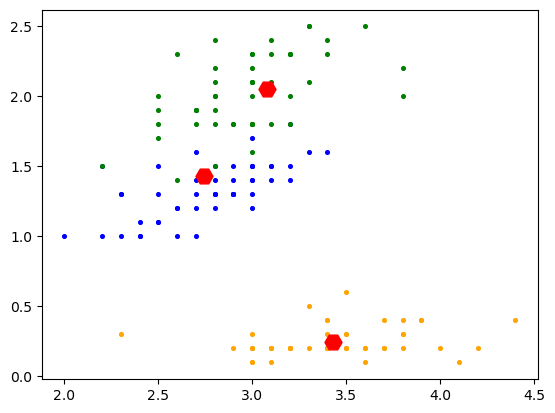

In [18]:
#
# Plot the data using columns 1 and 3
#
Kmean = KMeans(n_clusters=3, n_init='auto')
Kmean.fit(X)
centers = Kmean.cluster_centers_

for i in range(X.shape[0]):
    plt.scatter(X[i, 1], X[i, 3], s=7, color = colours[int(Y[i])])
plt.scatter(centers[:,1], centers[:,3], marker='H', c='r', s=150)
plt.show()

In [19]:
## From the previous graphs,
## we can spot that columns 2 and 3 provide the best separation along Y axis,
## so why not to try using them together

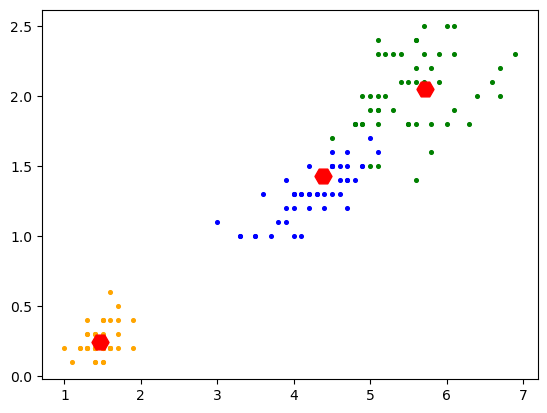

In [20]:
# Plot the data using columns 2 and 3
Kmean = KMeans(n_clusters=3, n_init='auto')
Kmean.fit(X)
centers = Kmean.cluster_centers_

for i in range(X.shape[0]):
    plt.scatter(X[i, 2], X[i, 3], s=7, color = colours[int(Y[i])])
plt.scatter(centers[:,2], centers[:,3], marker='H', c='r', s=150)
plt.show()

In [22]:
## Any classification tries not only to separate classes,
## but also to minimise the spread of each cluster
## (to provide more reliable classification)
## This is what we can see on the graph below for the orange cluster

In [23]:
## However, in reality we wouldn't be selecting 2 columns only out of 4
## Modern algorithms will use for classification all 4 inputs (for example, MLR)
## The quality of such system will be much higher comparing to SLR
##
## The only problem - it will be very difficult to visualise it
## There are ways to squeeze more than 2 variables onto a single graph -
## but it's not straightforward

In [ ]:
#
# Let's now use KMeans to predict the cluster on unseen data
#

In [ ]:
# 4 values
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# predict cluster 
cluster = Kmean.predict(new_flower)

# plot the new point
plt.scatter(new_flower[0][2], new_flower[0][3], c='black', s=100)